# Held-Out Validation: Does the Compounded Goldilocks Stack Generalize?

`11`, `12`, `13`, `14`, and `15` each picked their winning config by scoring against the
**same fixed 20 questions**, reused deliberately across all five notebooks so comparisons
within each notebook would be apples-to-apples. That was the right call for isolating one
variable at a time -- but it means five consecutive rounds of "pick the best config against
this exact sample" were run against a single 20-question draw. That's a real overfitting
risk: the final compounded pipeline (sentence+metadata chunks @ 64t -> hybrid BM25+dense
retrieval @ alpha=0.3 driven by HyDE doc+query -> Cohere Rerank 4-Pro over a candidate pool
of 20, kept to a final 2 chunks, no repacking) may be tuned to quirks of those specific 20
questions rather than DelucionQA generally.

This notebook doesn't search for anything new. It takes the fully compounded winning
pipeline exactly as-is and asks one question: **does it hold up on questions it has never
been evaluated against?**

- Re-score the pipeline on the **original 20 questions** (a sanity-check reproduction --
  `15`'s own fresh re-measurement of this exact config already landed at composite 0.682,
  not `14`'s originally reported 0.709, so this run's number is itself informative about
  run-to-run noise before comparing to anything held out).
- Score the same pipeline on a **fresh 20-question sample** never seen by `11`-`15`.
- Score it on the **combined 40 questions** for a less noisy overall estimate.

If the held-out composite lands in the same neighborhood as the original-sample composite,
the stack generalizes and the series' conclusions can be trusted. If it drops sharply, that
tells us which specific choices were overfit to the fixed sample -- worth knowing before
spending the (larger) effort on generator fine-tuning next.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever, OpenRouterReranker
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset -- Original Sample + Fresh Held-Out Sample

Loads enough source rows to get (at least) 40 unique questions, then splits them into the
**original** first-20 (the exact sample `11`-`15` optimized against) and a **held-out**
next-20 (never scored by any prior notebook in this series). The chunking corpus is built
from all documents across both samples, so the held-out questions' source documents are
actually present in the retrieval index -- this isn't a zero-shot-on-missing-data test, it's
a test of whether the pipeline's *configuration choices* generalize to different questions
over the same kind of corpus.

In [3]:
DATASET_NAME = "delucionqa"
SAMPLE_SIZE_PER_SPLIT = 20
TOTAL_UNIQUE_NEEDED = SAMPLE_SIZE_PER_SPLIT * 2

print("Loading dataset (enough rows for original + held-out splits)...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(TOTAL_UNIQUE_NEEDED + 15, 60))
n_unique = docs_df["row_id"].nunique()
print(f"✓ Loaded {len(docs_df)} documents from {n_unique} unique questions")
assert n_unique >= TOTAL_UNIQUE_NEEDED, (
    f"Need at least {TOTAL_UNIQUE_NEEDED} unique questions for two non-overlapping "
    f"20-question samples; only got {n_unique}. Increase num_samples above."
)

unique_questions_df = docs_df.drop_duplicates(subset=["row_id"]).reset_index(drop=True)
original_questions_df = unique_questions_df.iloc[:SAMPLE_SIZE_PER_SPLIT].reset_index(drop=True)
holdout_questions_df = unique_questions_df.iloc[SAMPLE_SIZE_PER_SPLIT:TOTAL_UNIQUE_NEEDED].reset_index(drop=True)
combined_questions_df = unique_questions_df.iloc[:TOTAL_UNIQUE_NEEDED].reset_index(drop=True)

assert set(original_questions_df["row_id"]).isdisjoint(set(holdout_questions_df["row_id"])), \
    "Original and held-out samples must not overlap"

print(f"✓ Original sample (11-15's fixed set):  {len(original_questions_df)} questions")
print(f"✓ Held-out sample (never scored before): {len(holdout_questions_df)} questions")
print(f"✓ Combined sample:                       {len(combined_questions_df)} questions")


Loading dataset (enough rows for original + held-out splits)...
✓ Loaded 180 documents from 60 unique questions
✓ Original sample (11-15's fixed set):  20 questions
✓ Held-out sample (never scored before): 20 questions
✓ Combined sample:                       40 questions


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: The Fully Compounded Winning Pipeline (unchanged from `11`-`15`)

No new configs, no sweeps -- this is `11`+`12`+`13`+`14`+`15`'s winning stack exactly as
each notebook left it:

- **Chunking** (`11`): sentence-level + metadata heading, 64-token target, 10% overlap
- **Retriever** (`12`): hybrid (BM25 + dense), alpha=0.3, wide candidate pool
- **Query transformation** (`13`): HyDE, one hypothetical document concatenated with the
  query, driving retrieval only
- **Reranker** (`14`): Cohere Rerank 4-Pro, candidate pool of 20
- **Final context** (`14`): top 2 reranked chunks, no repacking needed (`15`)

Built once over the combined 40-question corpus, so both the original and held-out
questions' source documents are indexed.

In [5]:
CHUNK_TARGET_TOKENS = 64
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.3
CANDIDATE_K = 20
FINAL_K = 2


def sentence_level_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = []
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        if not sentences:
            continue
        sent_tokens = [count_tokens(s) for s in sentences]
        n = len(sentences)
        i, chunk_idx = 0, 0
        while i < n:
            chunk_sents, chunk_tok_count, j = [], 0, i
            while j < n and (not chunk_sents or chunk_tok_count + sent_tokens[j] <= target_tokens):
                chunk_sents.append(sentences[j])
                chunk_tok_count += sent_tokens[j]
                j += 1
            chunk_text = " ".join(chunk_sents)
            documents.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_sent{chunk_idx}",
                    "row_id": doc["row_id"],
                    "tokens": count_tokens(chunk_text),
                },
            ))
            chunk_idx += 1
            overlap_count = int(len(chunk_sents) * overlap_fraction)
            step = max(len(chunk_sents) - overlap_count, 1)
            i += step
    return documents


def metadata_enhanced_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = sentence_level_chunks(docs_df, target_tokens=target_tokens, overlap_fraction=overlap_fraction)

    doc_id_to_heading = {}
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        heading = sentences[0] if sentences else doc["text"][:80]
        doc_id_to_heading[doc["doc_id"]] = " ".join(heading.split()[:12])

    enhanced = []
    for d in documents:
        source_doc_id = d.metadata["chunk_id"].rsplit("_sent", 1)[0]
        heading = doc_id_to_heading.get(source_doc_id, "")
        new_text = f"[Context: {heading}]\n{d.page_content}"
        enhanced.append(Document(
            page_content=new_text,
            metadata={**d.metadata, "tokens": count_tokens(new_text)},
        ))
    return enhanced


def apply_hyde(query, llm, n_docs=1, concat_with_query=True):
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


print("Building chunking foundation over the combined 40-question corpus...")
documents = metadata_enhanced_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print(f"Building wide hybrid retriever foundation (alpha=0.3, k={CANDIDATE_K})...")
wide_retriever = HybridRetriever(documents, embedding_model, k=CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                  dataset_name=DATASET_NAME, config_name="holdout_foundation")
print("✓ Wide hybrid retriever ready")

reranker = OpenRouterReranker("cohere/rerank-4-pro", openrouter_token)
print("✓ Cohere 4-Pro reranker ready")


Building chunking foundation over the combined 40-question corpus...
✓ Built 1020 chunks, avg 69 tokens/chunk
Building wide hybrid retriever foundation (alpha=0.3, k=20)...
✓ Wide hybrid retriever ready
✓ Cohere 4-Pro reranker ready


## Step 6: Evaluation Runner (identical to `14`/`15`)

No changes to the pipeline logic -- same HyDE-transform -> retrieve -> rerank -> generate ->
retry-annotate -> composite flow used throughout this series, run here against whichever
question sample is passed in.

In [6]:
def evaluate_pipeline(config_name, questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    for _, row in questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=1, concat_with_query=True)
            candidates = wide_retriever.retrieve(retrieval_query)[:CANDIDATE_K]
            reranked_docs = reranker.rerank(original_question, candidates, top_k=FINAL_K)
            retrieved_texts = [d.page_content for d in reranked_docs]

            response_text = rag_chain.invoke({"context": format_docs(reranked_docs), "question": original_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "n_questions": len(questions_df),
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_pipeline defined")


✓ evaluate_pipeline defined


## Step 7: Run All Three Evaluations

Same pipeline, three question samples: the original fixed set `11`-`15` optimized against,
the fresh held-out set, and the combined 40 for a lower-variance overall estimate.

In [7]:
print("=" * 100)
print("HELD-OUT VALIDATION: SAME PIPELINE, THREE QUESTION SAMPLES")
print("=" * 100)

validation_results = []

print("\n--- original (11-15's fixed 20 questions) ---")
result = evaluate_pipeline("original_20", original_questions_df)
validation_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
          f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
          f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{result['n_questions']})")

print("\n--- held-out (fresh 20 questions, never scored before) ---")
result = evaluate_pipeline("holdout_20", holdout_questions_df)
validation_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
          f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
          f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{result['n_questions']})")

print("\n--- combined (all 40 questions) ---")
result = evaluate_pipeline("combined_40", combined_questions_df)
validation_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
          f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
          f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{result['n_questions']})")

validation_df = pd.DataFrame(validation_results)
print("\n" + "=" * 100)
print("VALIDATION RESULTS")
print("=" * 100)
display(validation_df)


HELD-OUT VALIDATION: SAME PIPELINE, THREE QUESTION SAMPLES

--- original (11-15's fixed 20 questions) ---
  CR=0.6051 Util=0.3858 Comp=0.6795 Adh=0.9500 Composite=0.7041  (failed 0/20)

--- held-out (fresh 20 questions, never scored before) ---
  CR=0.5962 Util=0.3635 Comp=0.5950 Adh=0.9500 Composite=0.6849  (failed 0/20)

--- combined (all 40 questions) ---
  CR=0.5932 Util=0.3849 Comp=0.6633 Adh=0.9500 Composite=0.6974  (failed 0/40)

VALIDATION RESULTS


,config,n_questions,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,original_20,20,20,0,0.605140,0.385840,0.679525,0.95,0.704104
1,holdout_20,20,20,0,0.596190,0.363460,0.595000,0.95,0.684935
2,combined_40,40,40,0,0.593185,0.384912,0.663335,0.95,0.697352


## Step 8: Visualize the Generalization Gap

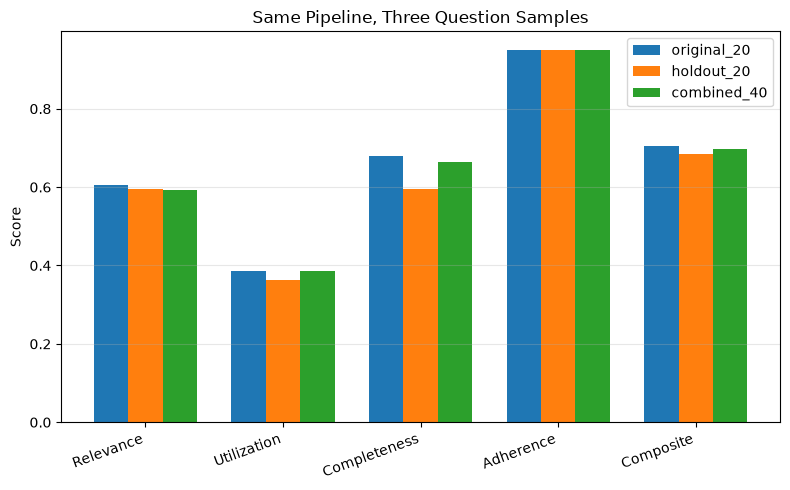

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ["context_relevance", "utilization", "completeness", "adherence", "composite"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (_, row) in enumerate(validation_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=row["config"])

ax.set_xticks(x + width)
ax.set_xticklabels(["Relevance", "Utilization", "Completeness", "Adherence", "Composite"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Same Pipeline, Three Question Samples")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## Step 9: Verdict -- Does the Stack Generalize?

In [9]:
original_row = validation_df[validation_df["config"] == "original_20"].iloc[0]
holdout_row = validation_df[validation_df["config"] == "holdout_20"].iloc[0]
combined_row = validation_df[validation_df["config"] == "combined_40"].iloc[0]

print("=" * 100)
print("GENERALIZATION CHECK")
print("=" * 100)

if original_row["composite"] is not None and holdout_row["composite"] is not None:
    gap = holdout_row["composite"] - original_row["composite"]
    print(f"\nOriginal sample composite:  {original_row['composite']:.4f}")
    print(f"Held-out sample composite:  {holdout_row['composite']:.4f}")
    print(f"Gap (held-out - original):  {gap:+.4f}")
    print(f"Combined 40-question composite: {combined_row['composite']:.4f}")

    print("\nFor reference, this series' own noise floor:")
    print("  15's fresh re-measurement of this exact config landed at composite 0.682,")
    print("  vs. 0.709 originally reported in 14 for the nominally identical config --")
    print("  a ~0.03 spread from run-to-run noise alone (temperature-0.7 HyDE generation,")
    print("  stochastic judge annotation) on the SAME question sample.")

    print("\n" + "-" * 100)
    if abs(gap) <= 0.05:
        print("✅ VERDICT: Held-out composite is within/near the series' own observed noise floor.")
        print("   The compounded pipeline generalizes -- 11-15's conclusions can be trusted as")
        print("   reflecting real properties of this dataset/pipeline combination, not overfitting")
        print("   to the specific fixed 20-question sample.")
    elif gap < -0.05:
        print("⚠️  VERDICT: Held-out composite drops meaningfully below the original sample.")
        print("   Some of 11-15's winning choices may be overfit to the fixed sample's specific")
        print("   questions. Worth re-examining which phase's margin was narrowest before")
        print("   treating the compounded stack as final.")
    else:
        print("📈 VERDICT: Held-out composite is meaningfully HIGHER than the original sample.")
        print("   Possible explanations: the original 20-question sample happened to be a harder")
        print("   draw, or genuine variance -- not evidence of a problem, but worth another sample")
        print("   before concluding the pipeline is unusually strong.")
    print("-" * 100)
else:
    print("Could not compute gap -- one or both samples had no successful evaluations.")
print("=" * 100)


GENERALIZATION CHECK

Original sample composite:  0.7041
Held-out sample composite:  0.6849
Gap (held-out - original):  -0.0192
Combined 40-question composite: 0.6974

For reference, this series' own noise floor:
  15's fresh re-measurement of this exact config landed at composite 0.682,
  vs. 0.709 originally reported in 14 for the nominally identical config --
  a ~0.03 spread from run-to-run noise alone (temperature-0.7 HyDE generation,
  stochastic judge annotation) on the SAME question sample.

----------------------------------------------------------------------------------------------------
✅ VERDICT: Held-out composite is within/near the series' own observed noise floor.
   The compounded pipeline generalizes -- 11-15's conclusions can be trusted as
   reflecting real properties of this dataset/pipeline combination, not overfitting
   to the specific fixed 20-question sample.
----------------------------------------------------------------------------------------------------


### Caveats -- do not treat these exact numbers as final

- **Still only 20+20 questions.** This raises the sample size from one 20-question draw to
  two, plus a combined 40, but RAGBench's DelucionQA split has far more than 40 questions
  available -- a larger validation (e.g. 50+50) would narrow the noise floor further.
- **The held-out questions' source documents were still indexed alongside the original
  ones** in a single combined vector store/BM25 index -- this tests whether the pipeline's
  *configuration* generalizes to new questions over a similar corpus, not whether it
  generalizes to a genuinely unseen corpus.
- **`query_llm` runs at temperature 0.7** for HyDE generation, and judge annotation is
  inherently somewhat stochastic -- both samples' composite scores carry that same noise
  source independently.
- **No new configuration choices were tested here.** This notebook validates `11`-`15`'s
  existing winning stack; it doesn't re-search chunking, retrieval, query transformation,
  reranking, or repacking against the held-out sample. A meaningfully large held-out gap
  would motivate a follow-up re-search, not just a note in this notebook.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`-`15` for comparability.
